# H4 — Aumento en la frecuencia e intensidad de temperaturas extremas

Analizamos si los días con temperaturas extremas (Tmax > 35°C) son más frecuentes, y si las **olas de calor** (episodios de ≥3 días consecutivos) son más largas e intensas en las últimas décadas.

## 1. Imports y carga de datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.variables import CIUDADES, crear_dirs
from scripts.funciones_variables import cargar_datos
from scripts.analisis import temperaturas, olas_calor
from scripts.graficos import graficos_temp, graficos_olas_calor

crear_dirs()
cargar_datos()

📂 Cargando datos...
  ✅ bilbo: 31,412 filas
  ✅ donostia: 31,412 filas
  ✅ gasteiz: 31,412 filas
  ✅ iruna: 31,412 filas
  ✅ baiona: 31,412 filas
  ✅ arrasate: 31,412 filas
  ✅ maule: 31,412 filas



## 2. Días con temperatura extrema (Tmax > 35°C)

Número de días al año que superan los 35°C. Diferenciamos entre amarillo (1–3 días), rojo (4–7) y granate (≥8). Se anotan los años con 8 o más días extremos.

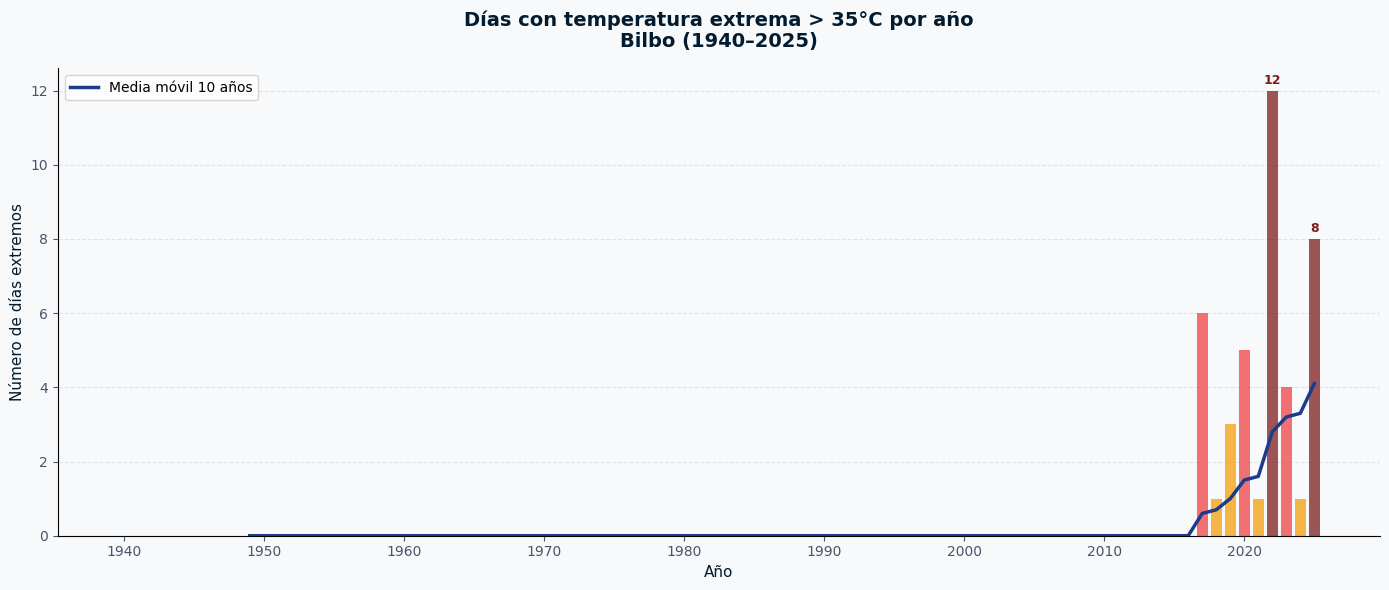

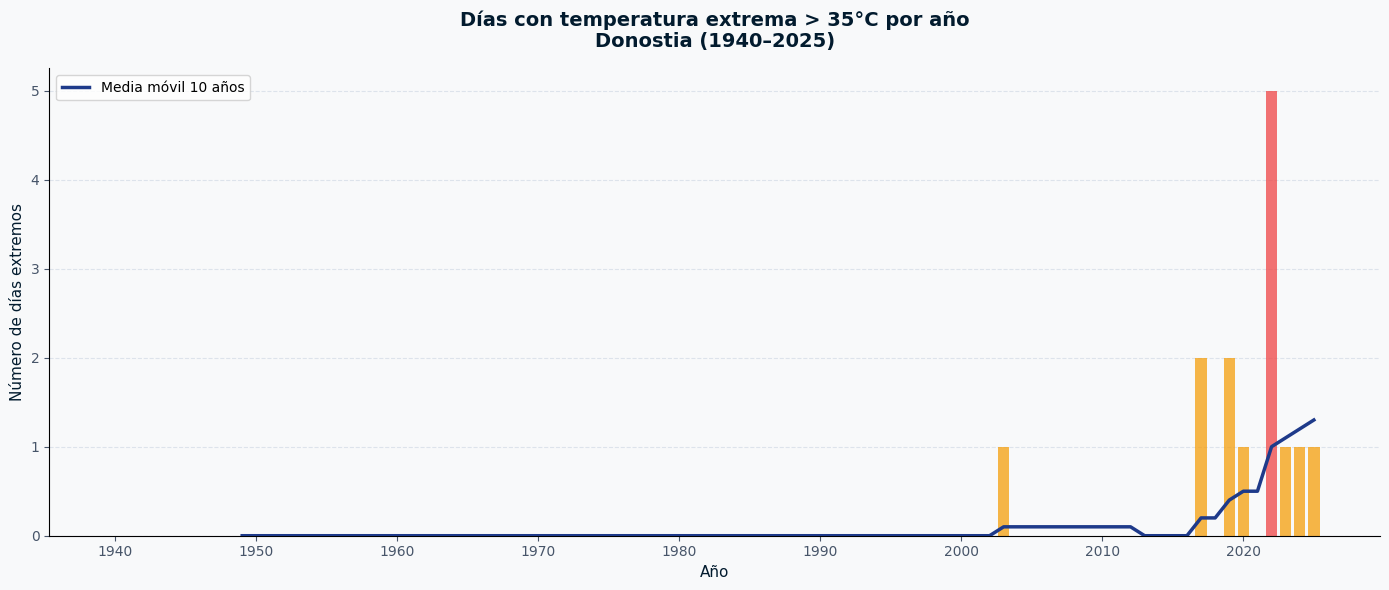

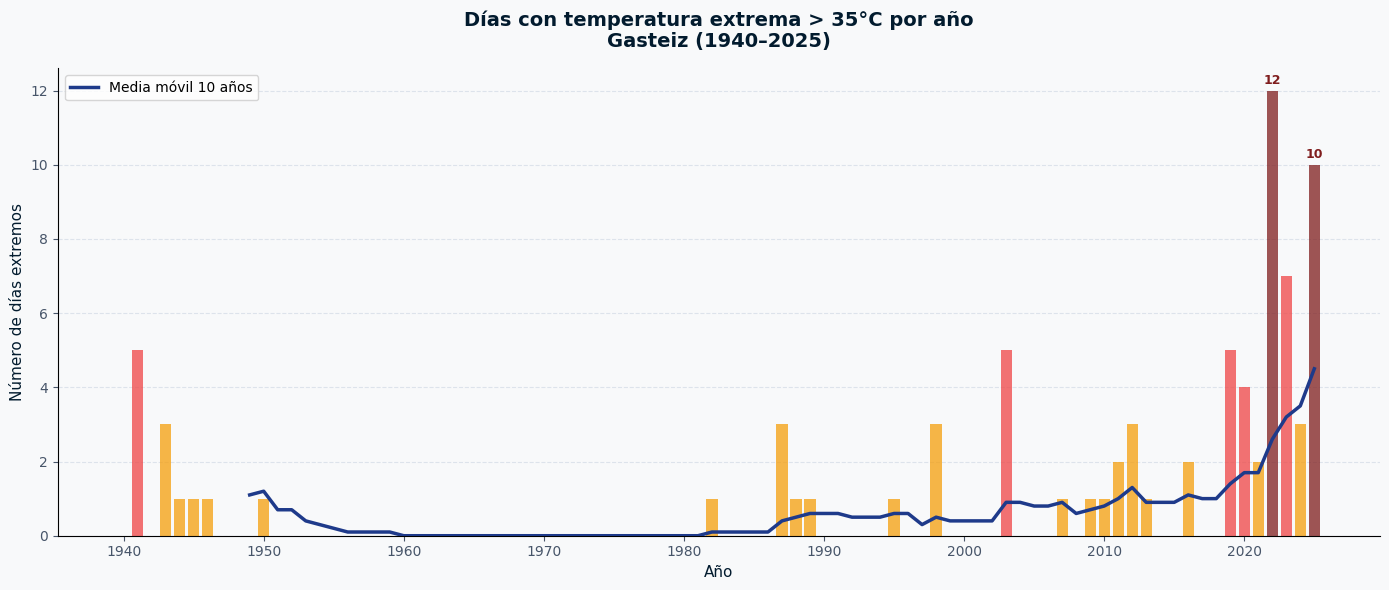

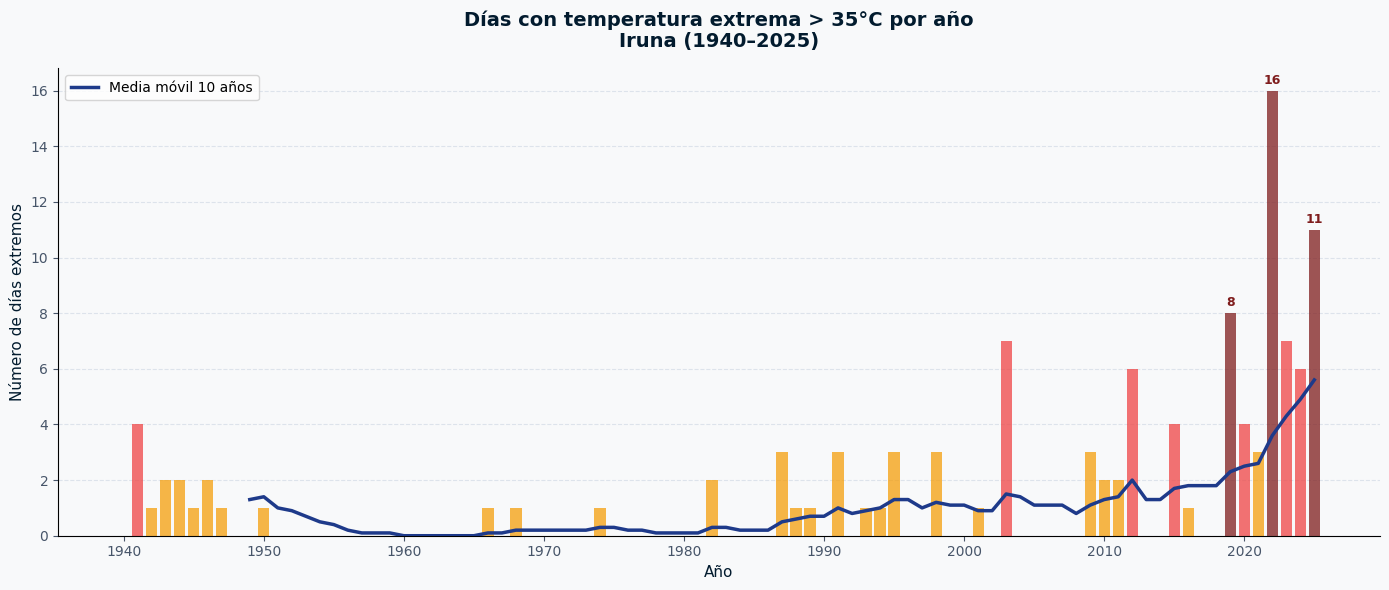

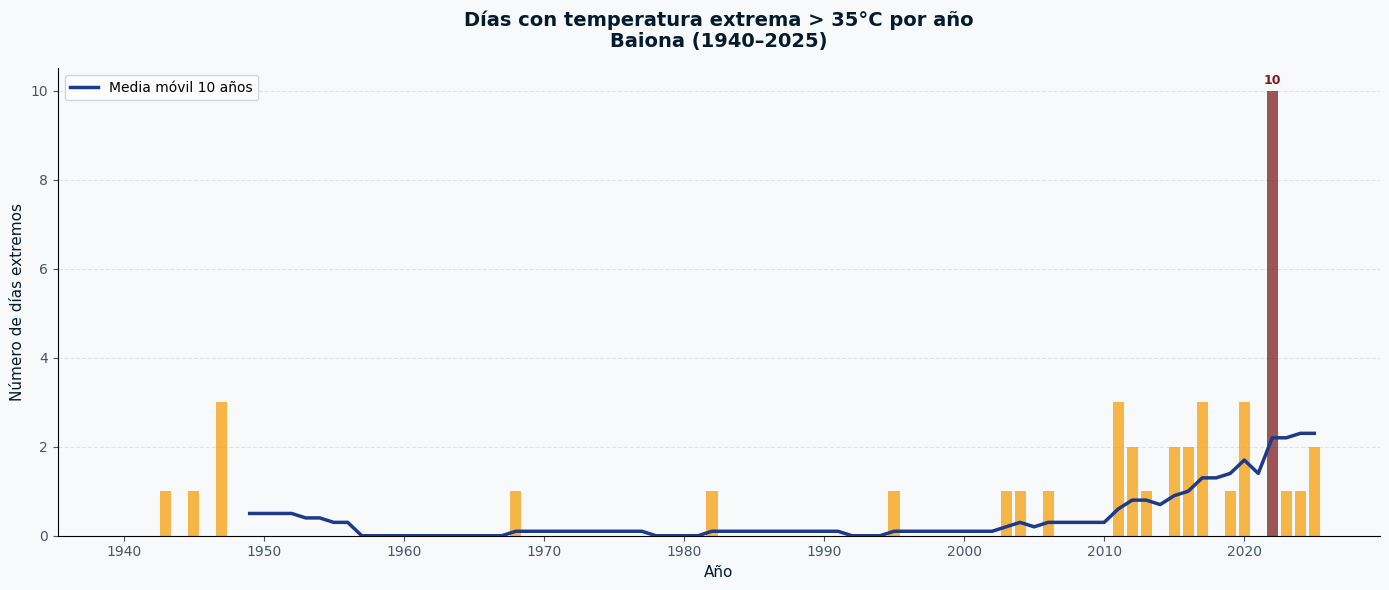

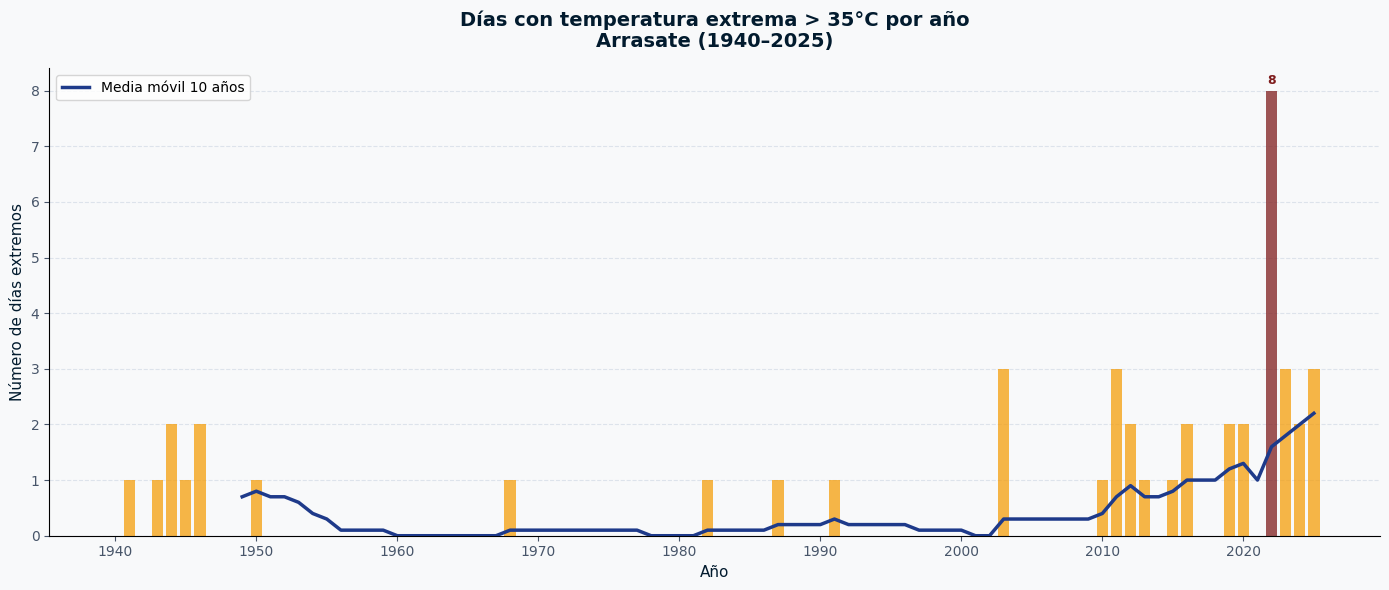

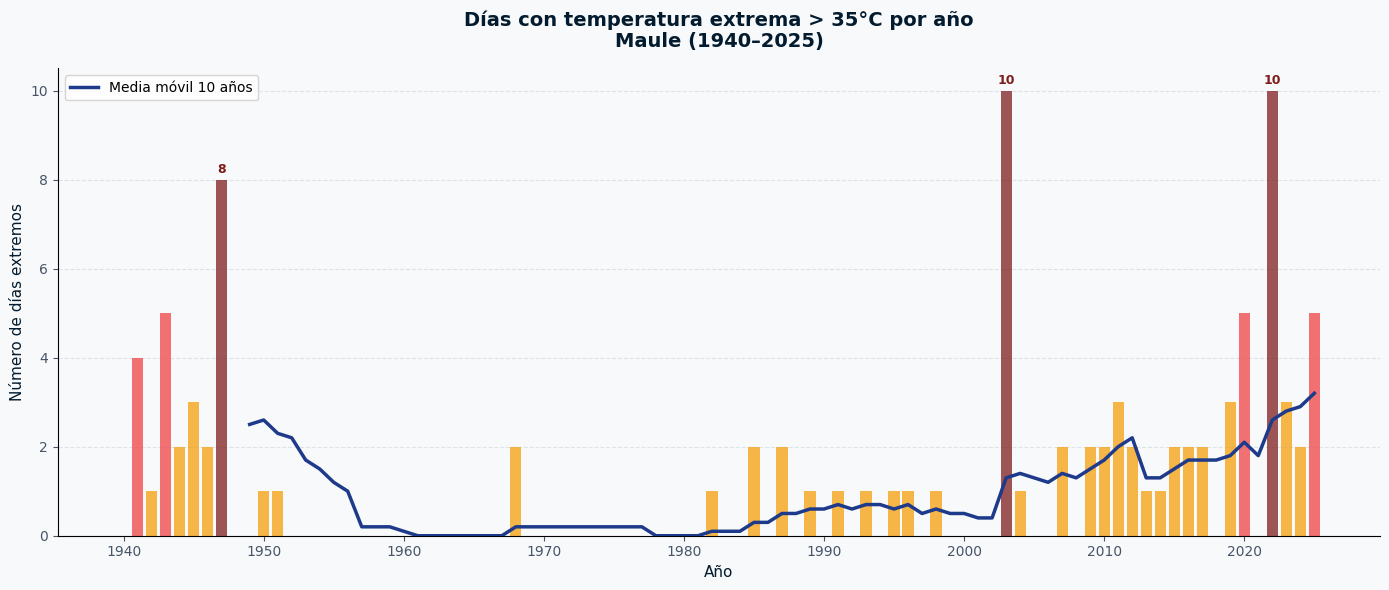

In [2]:
datos_temp = temperaturas.calcular_todos()
graficos_temp.graficar_dias_extremos(datos_temp['dias_extremos'])

## 3. Distribución de temperatura máxima por décadas (boxplot)

No solo la frecuencia de extremos, sino la distribución completa de Tmax cambia con las décadas. Un desplazamiento hacia la derecha de los boxplots recientes confirma el calentamiento estructural.

/Users/nora/Documentos_Clase/BOOTCAMP/EDA/scripts/graficos/graficos_temp.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


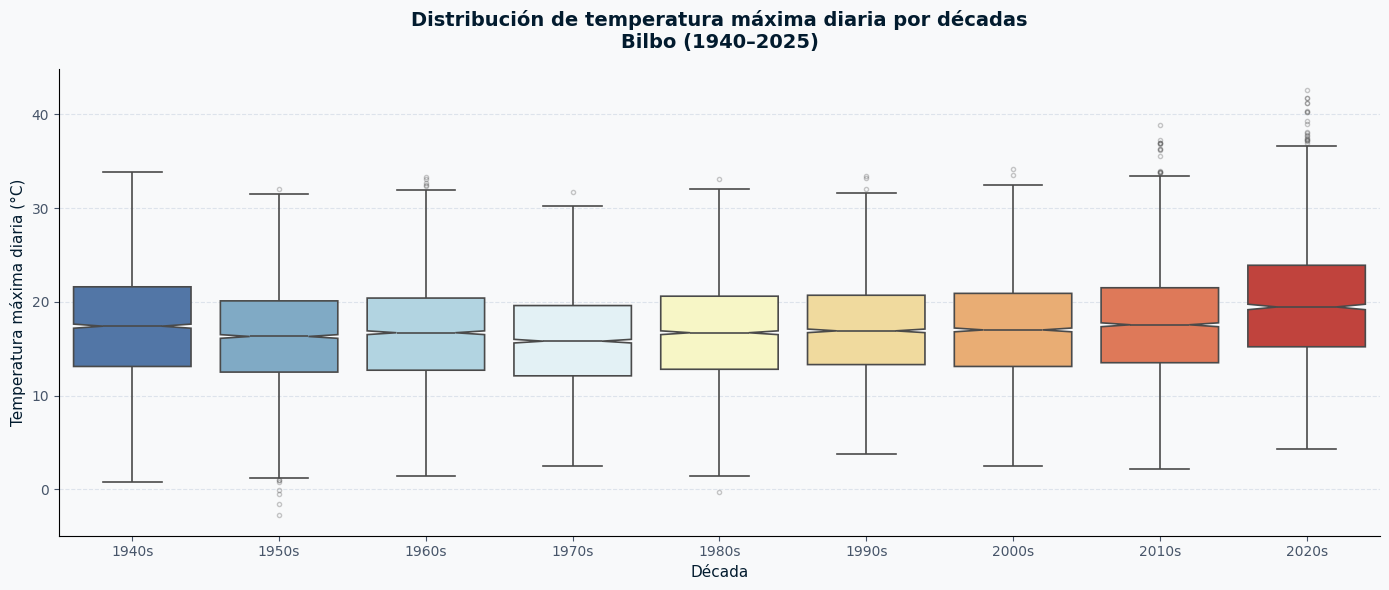

/Users/nora/Documentos_Clase/BOOTCAMP/EDA/scripts/graficos/graficos_temp.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


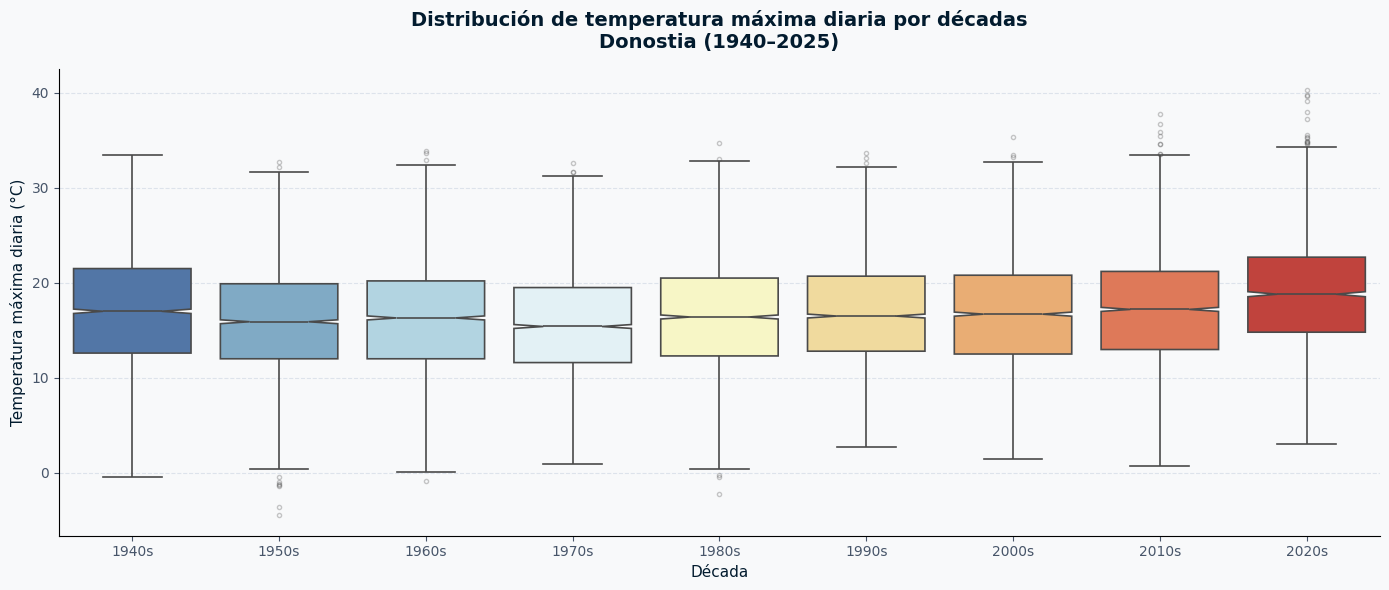

/Users/nora/Documentos_Clase/BOOTCAMP/EDA/scripts/graficos/graficos_temp.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


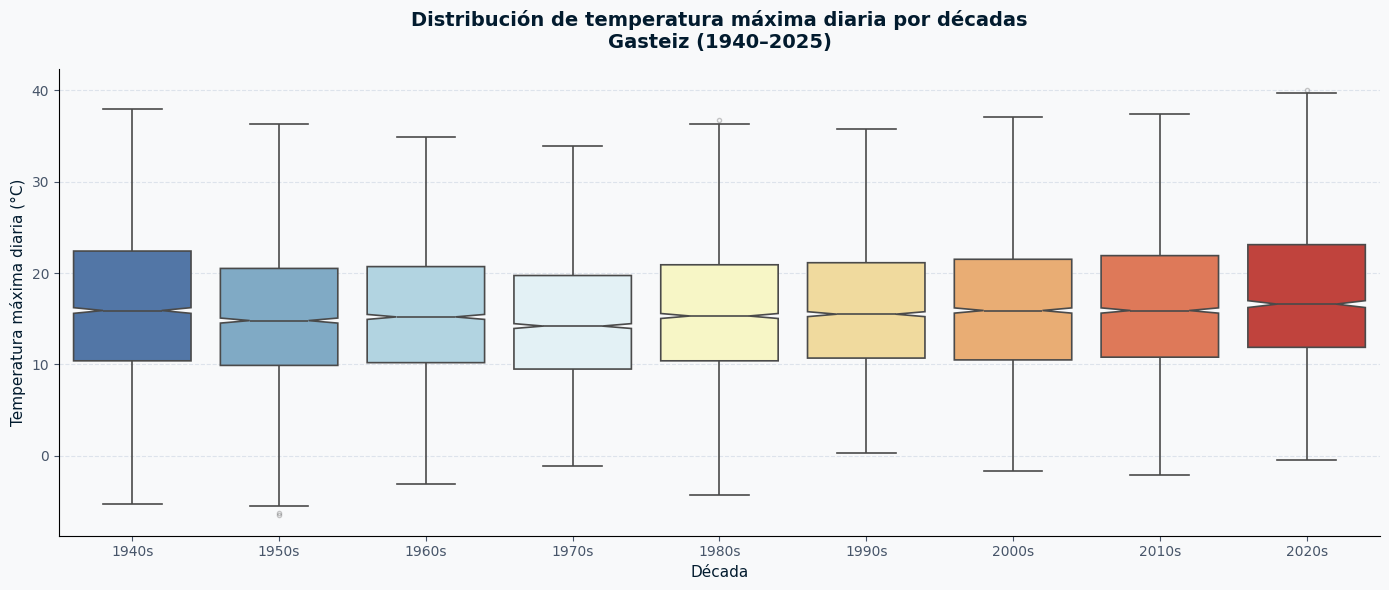

/Users/nora/Documentos_Clase/BOOTCAMP/EDA/scripts/graficos/graficos_temp.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


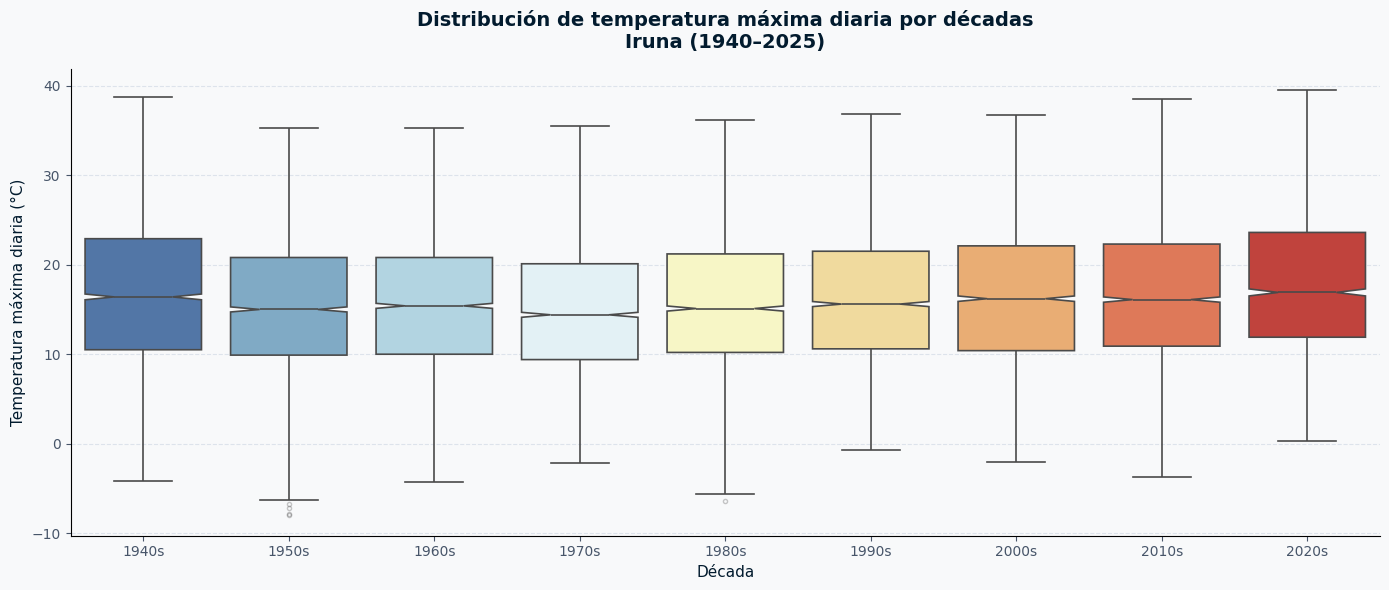

/Users/nora/Documentos_Clase/BOOTCAMP/EDA/scripts/graficos/graficos_temp.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


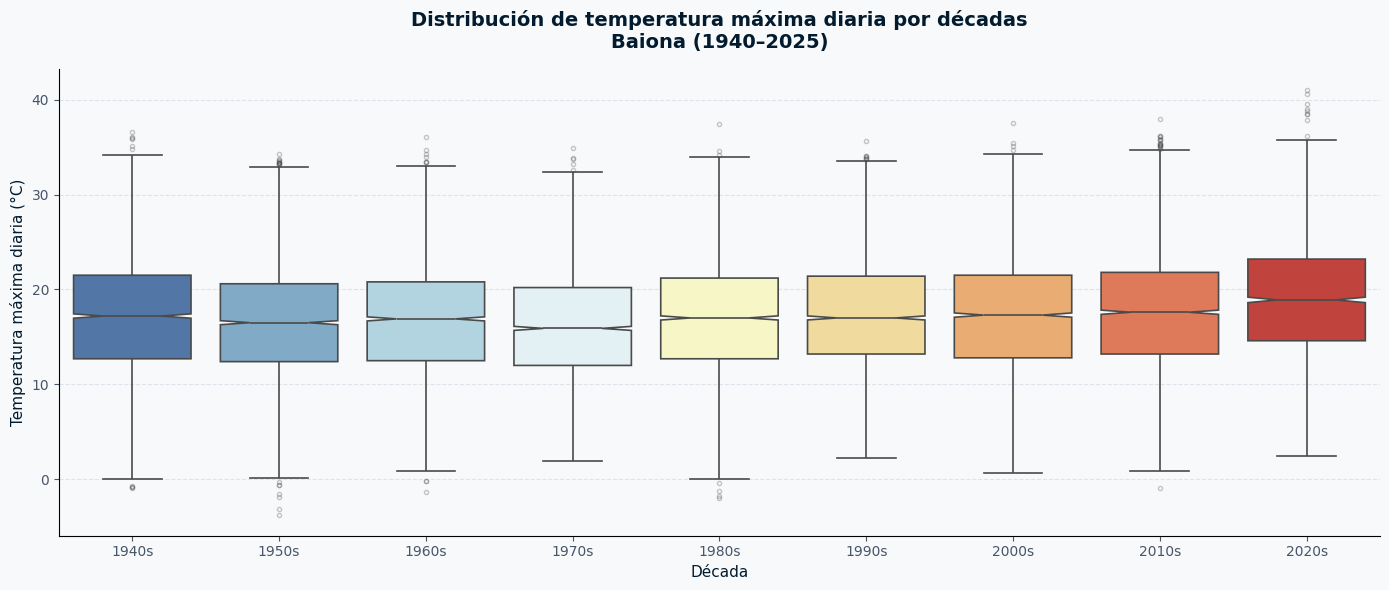

/Users/nora/Documentos_Clase/BOOTCAMP/EDA/scripts/graficos/graficos_temp.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


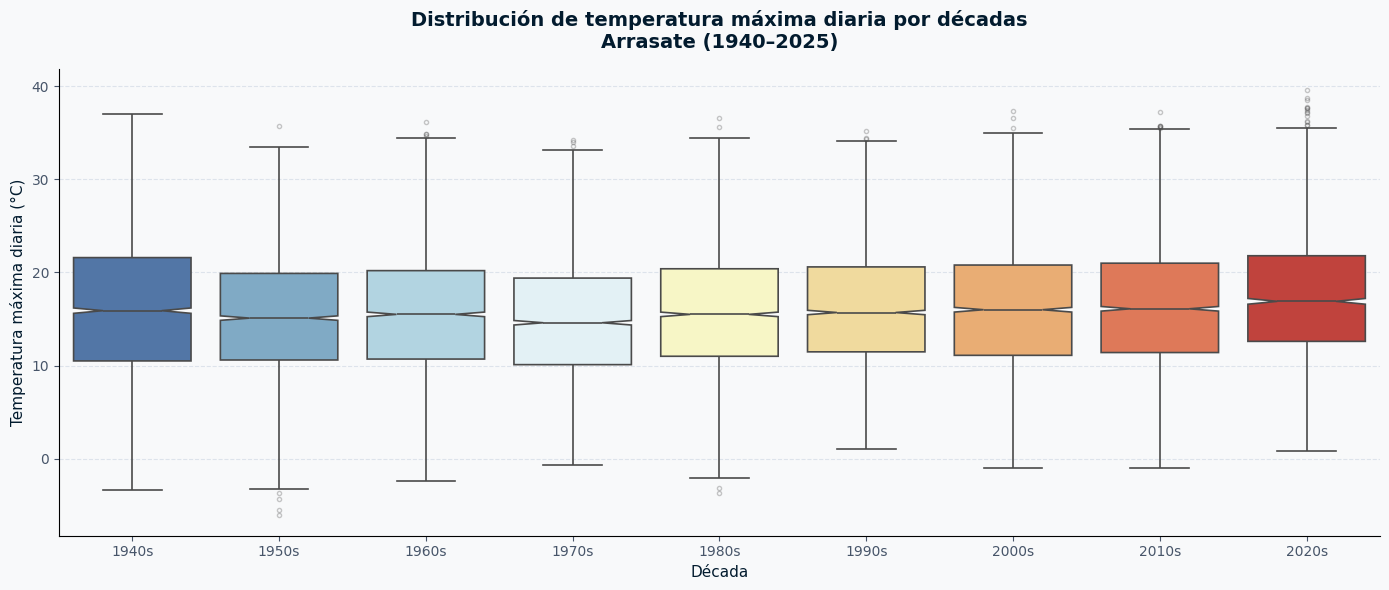

/Users/nora/Documentos_Clase/BOOTCAMP/EDA/scripts/graficos/graficos_temp.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


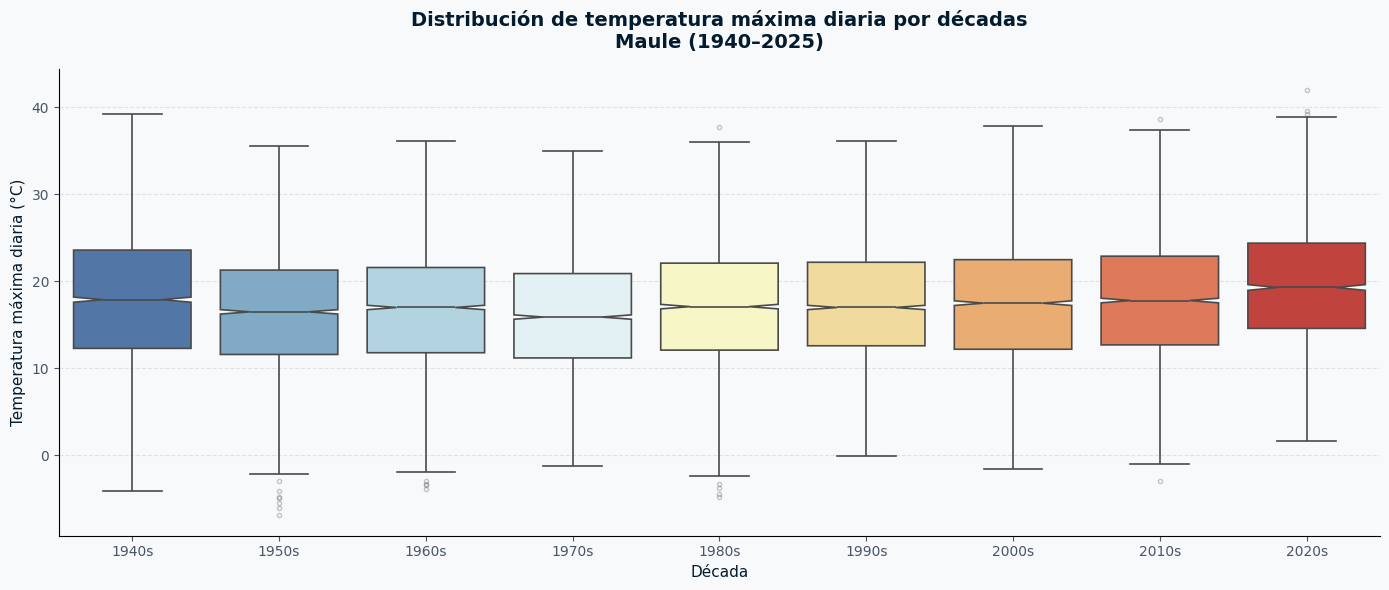

In [3]:
graficos_temp.graficar_boxplot_decadas(CIUDADES)

## 4. Número y duración de olas de calor

Detectamos **olas de calor** como episodios de ≥3 días consecutivos con Tmax > 35°C. Mostramos por año: cuántas olas hubo y cuántos días duró la más larga.

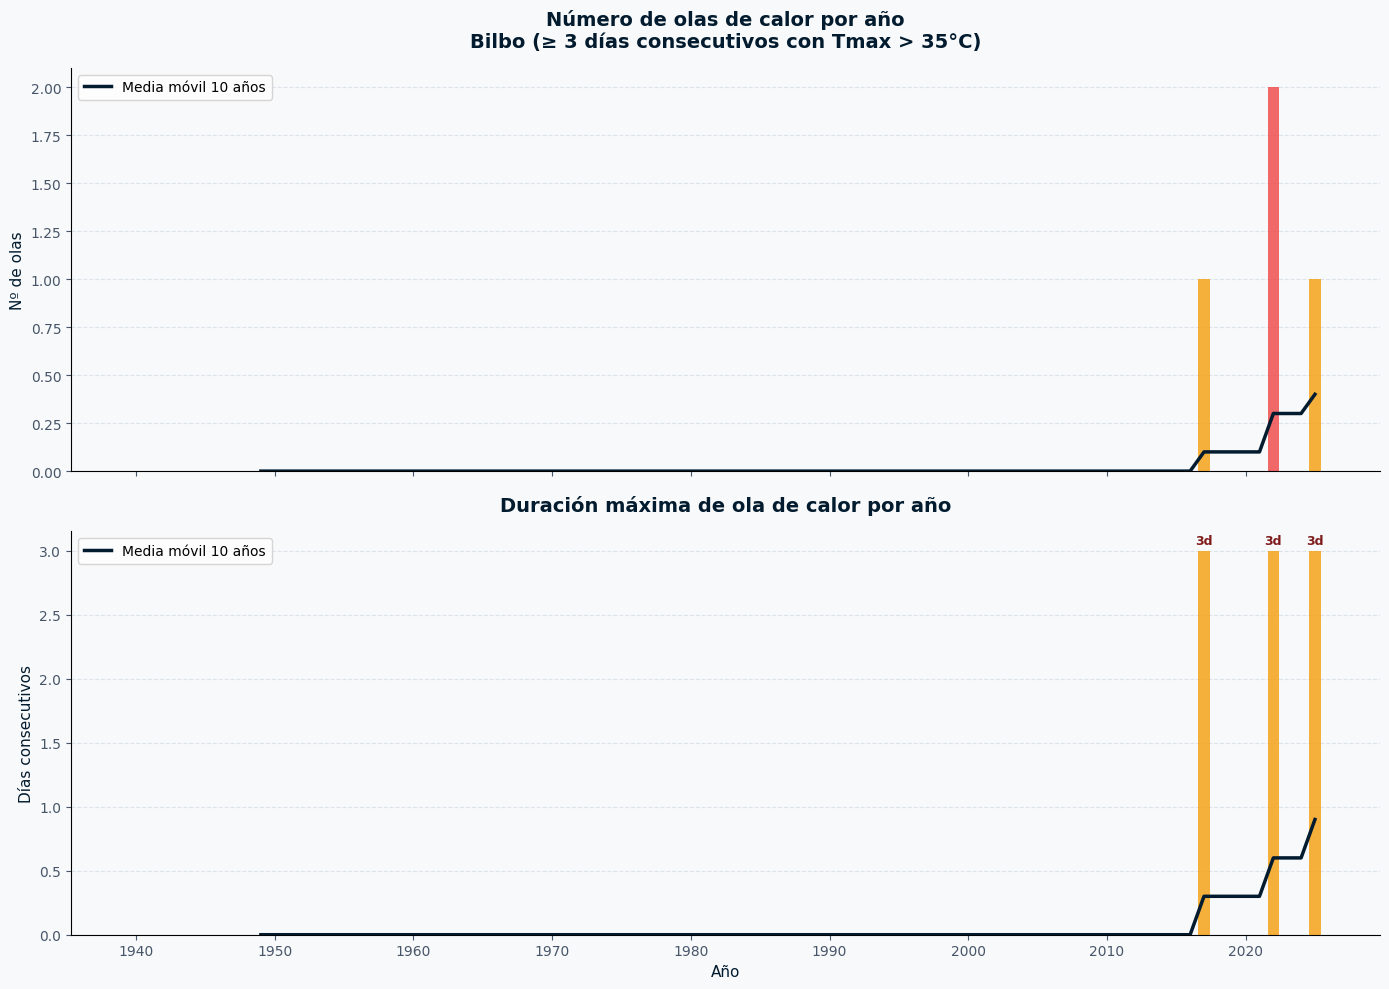

  ⚠️  donostia: sin olas de calor detectadas


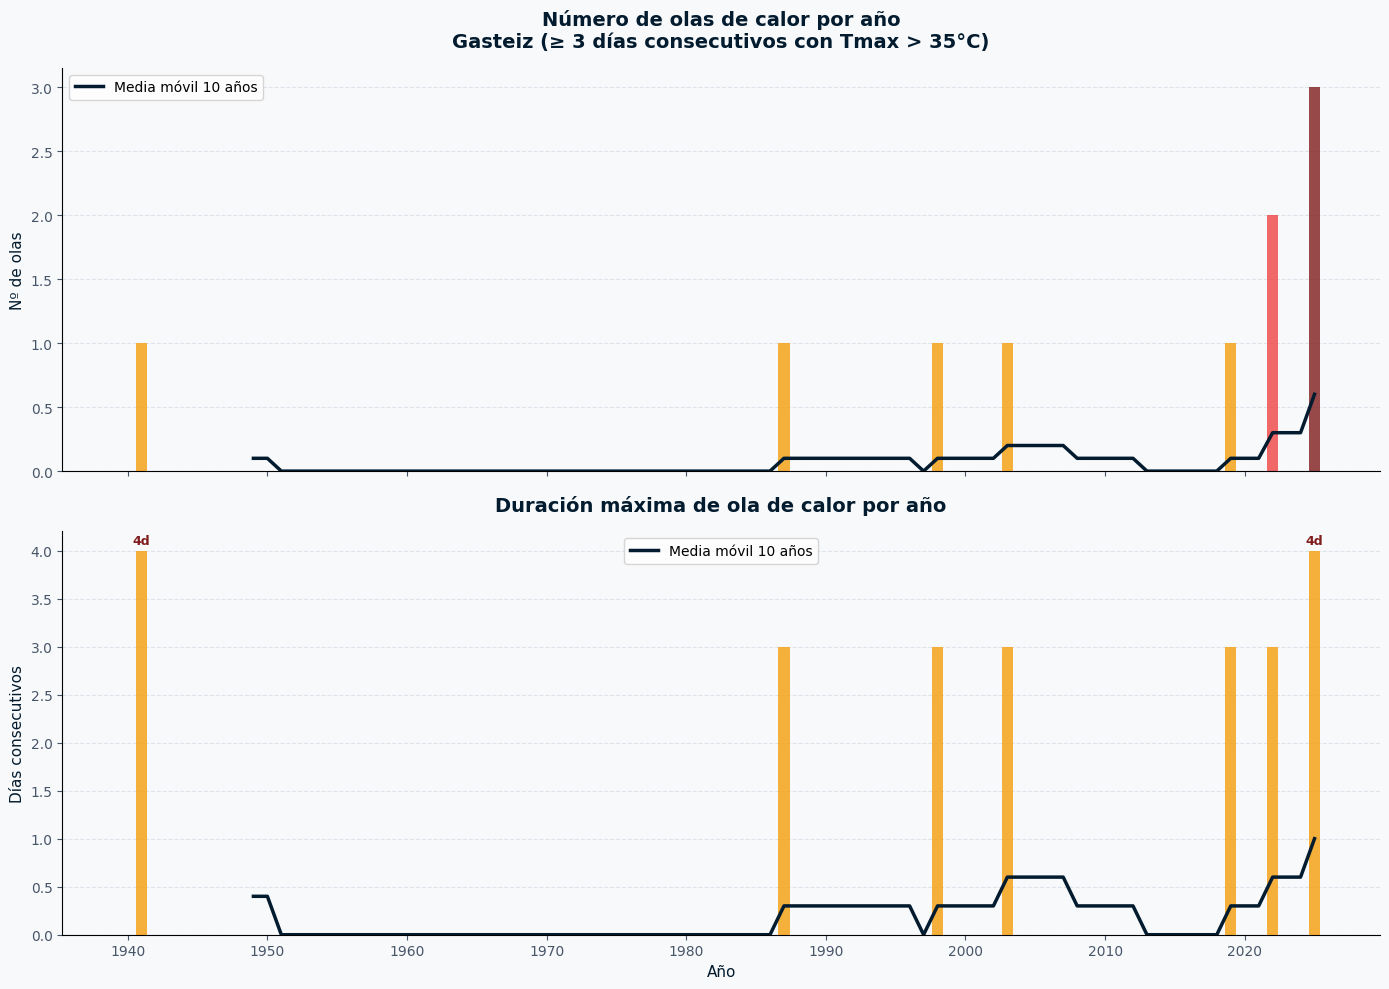

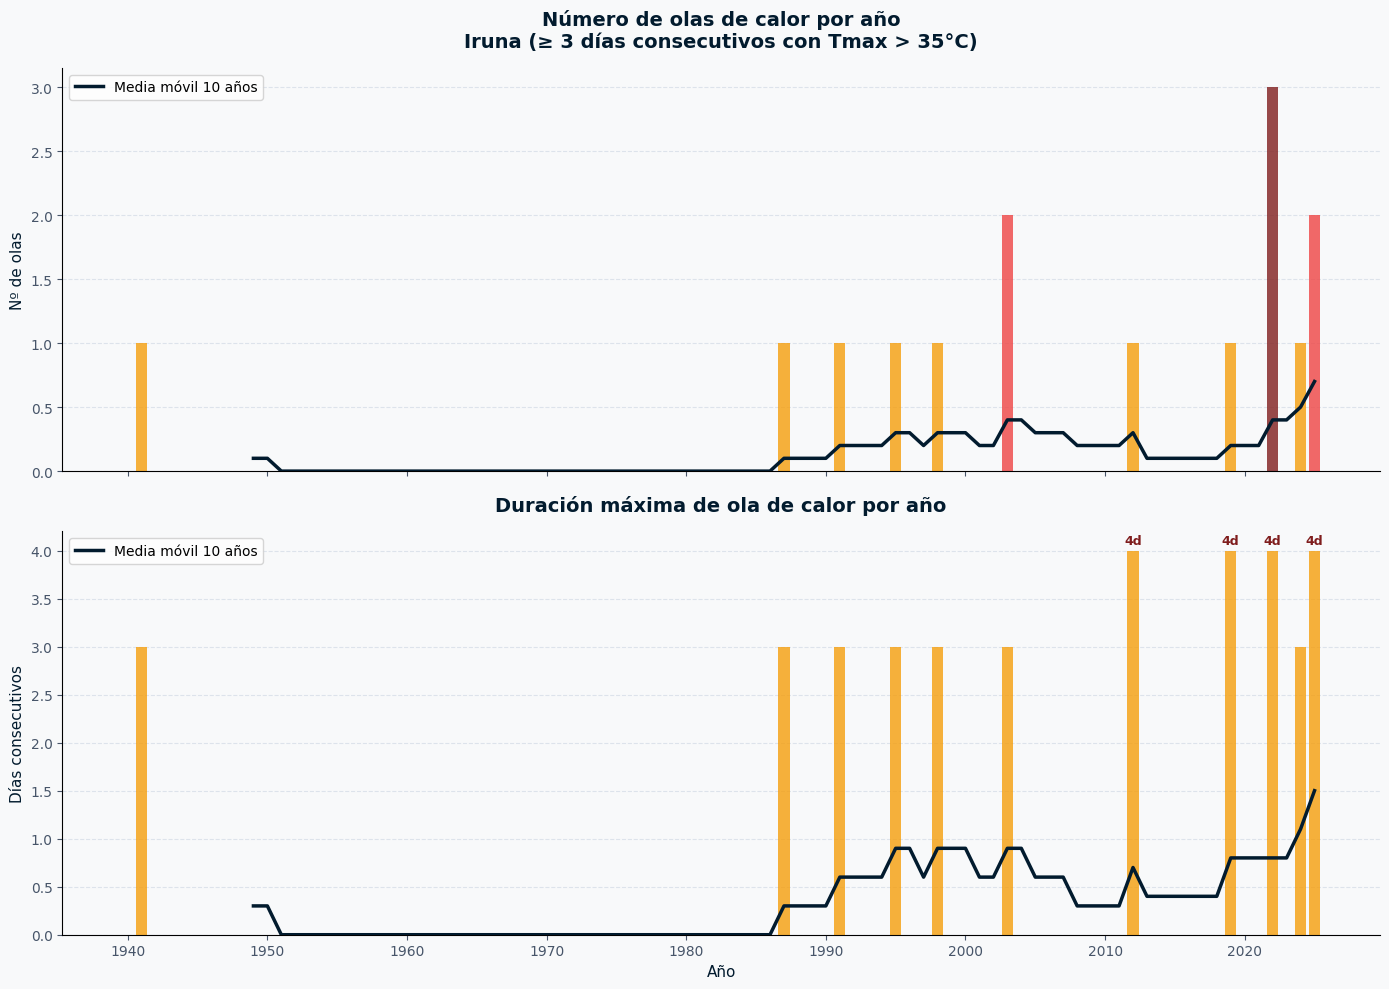

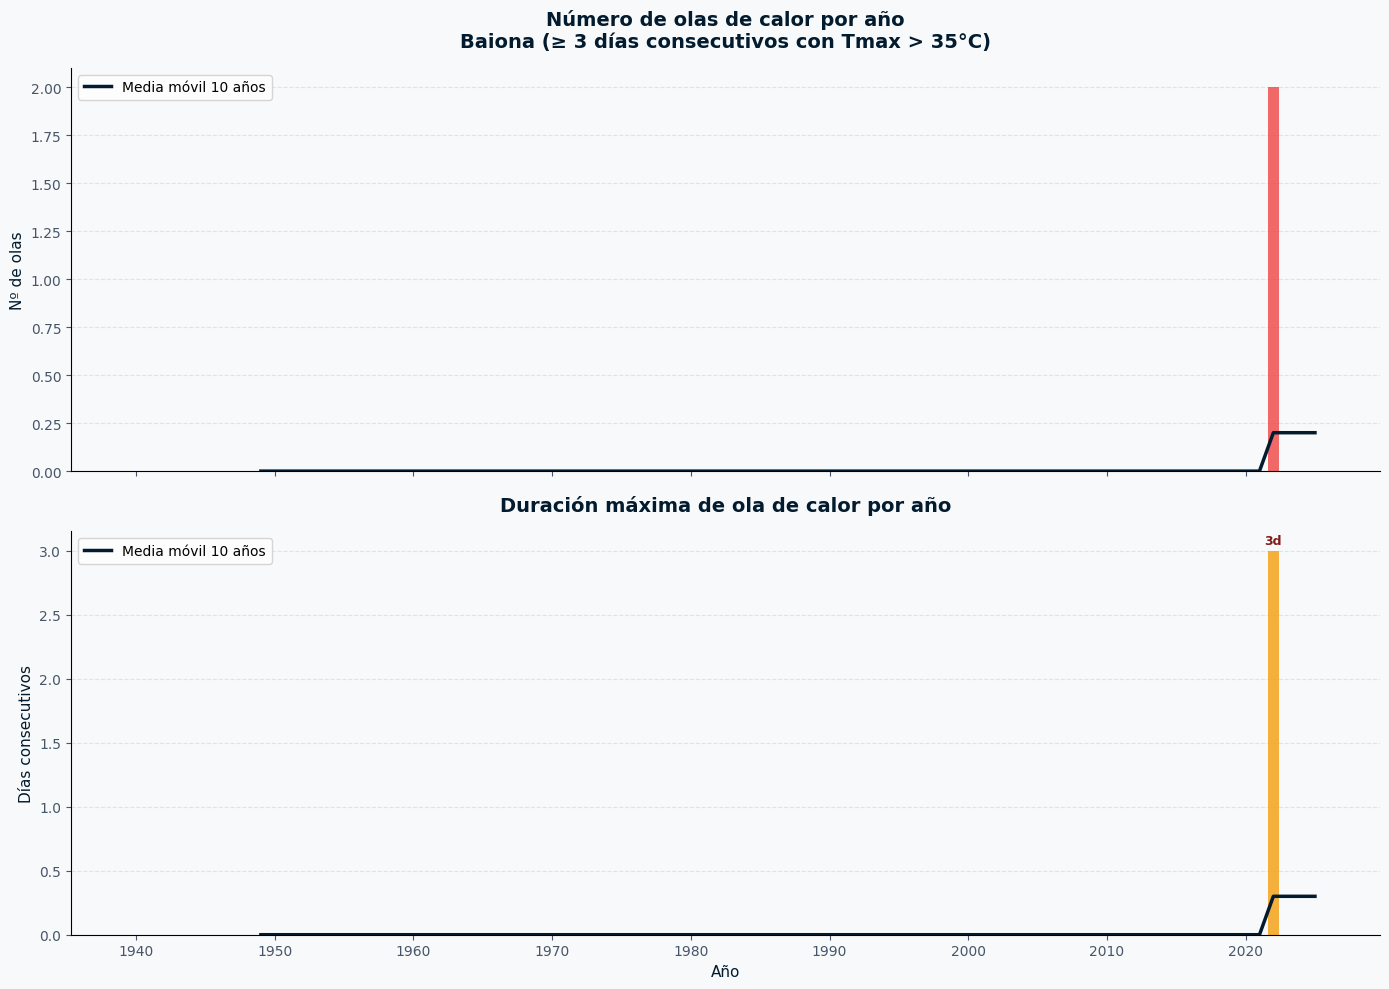

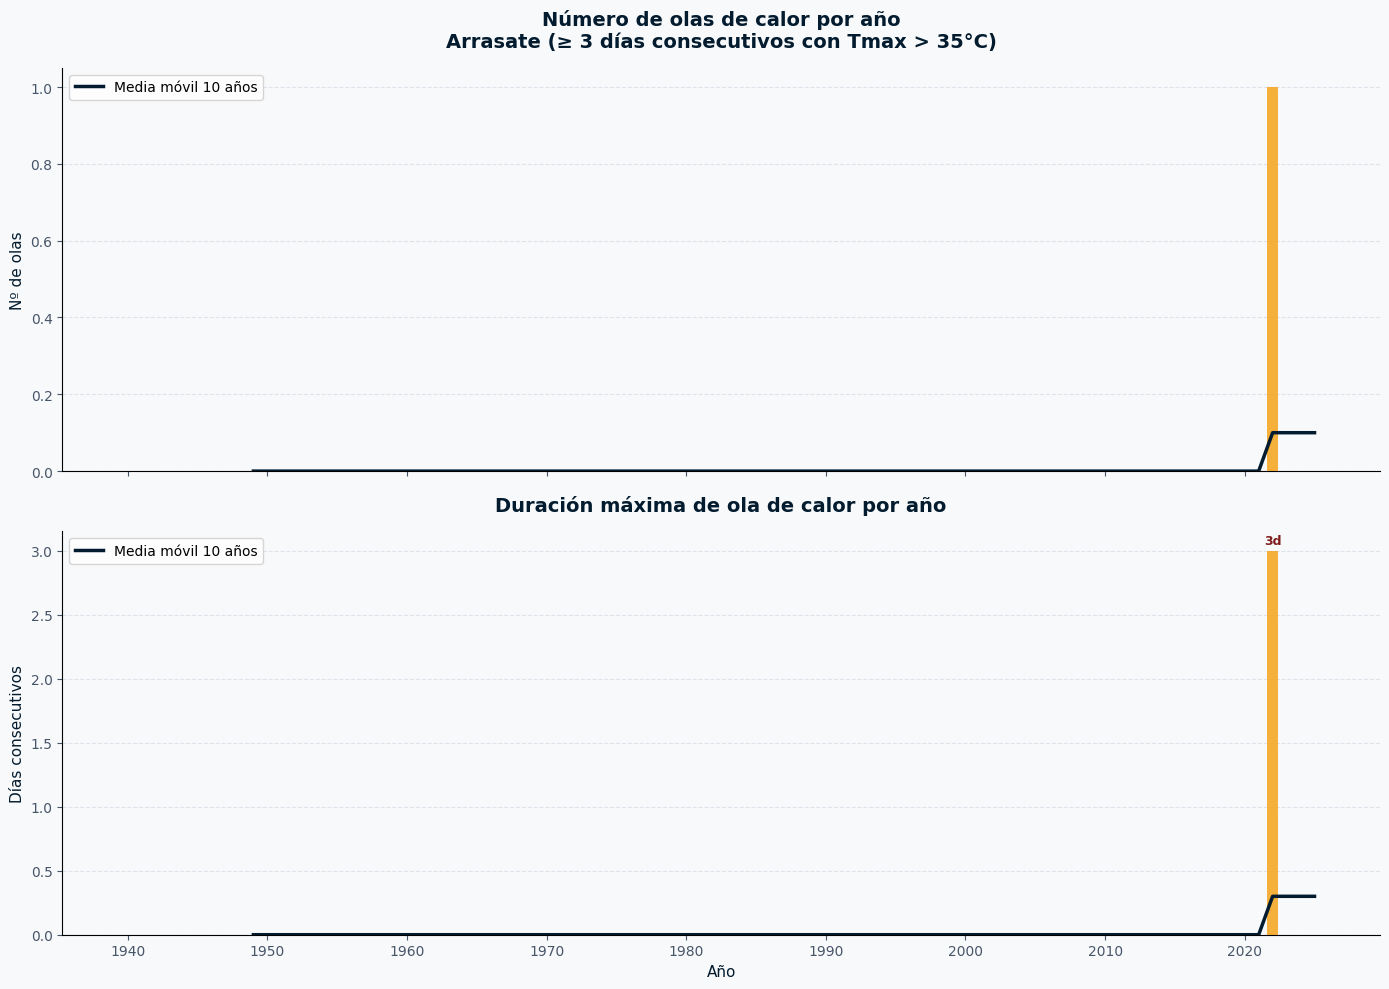

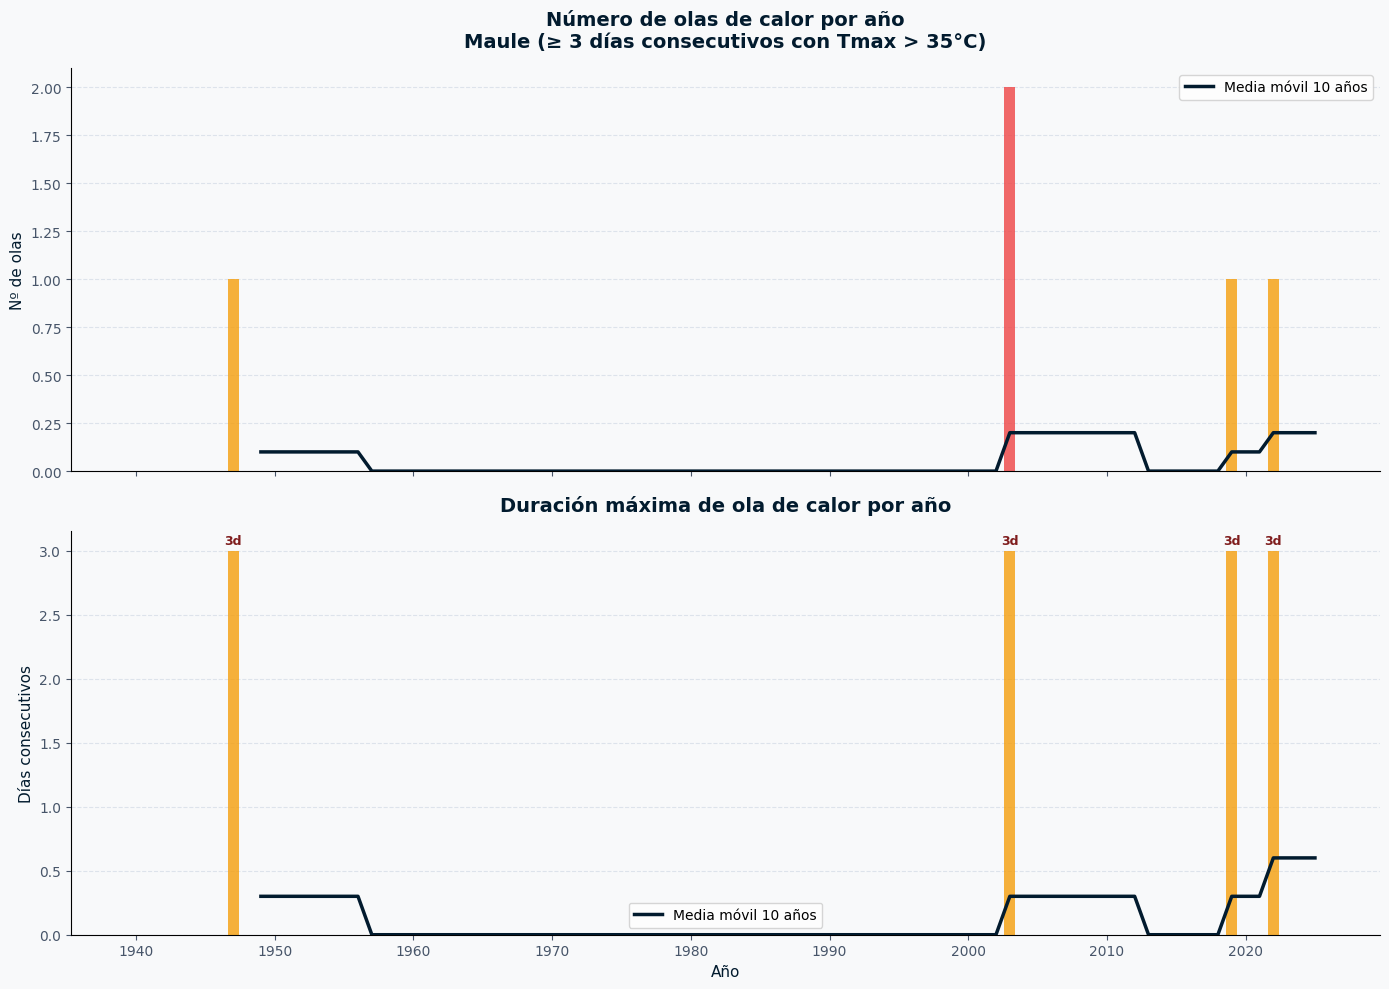

In [4]:
datos_olas = olas_calor.calcular_todos()
graficos_olas_calor.graficar_duracion_olas(datos_olas)

## 5. Calendario de olas de calor (heatmap ciudad × año)

Heatmap que muestra los días totales en ola de calor para cada ciudad y año. Una lectura de izquierda a derecha debería mostrar un aumento de color hacia las décadas más recientes.

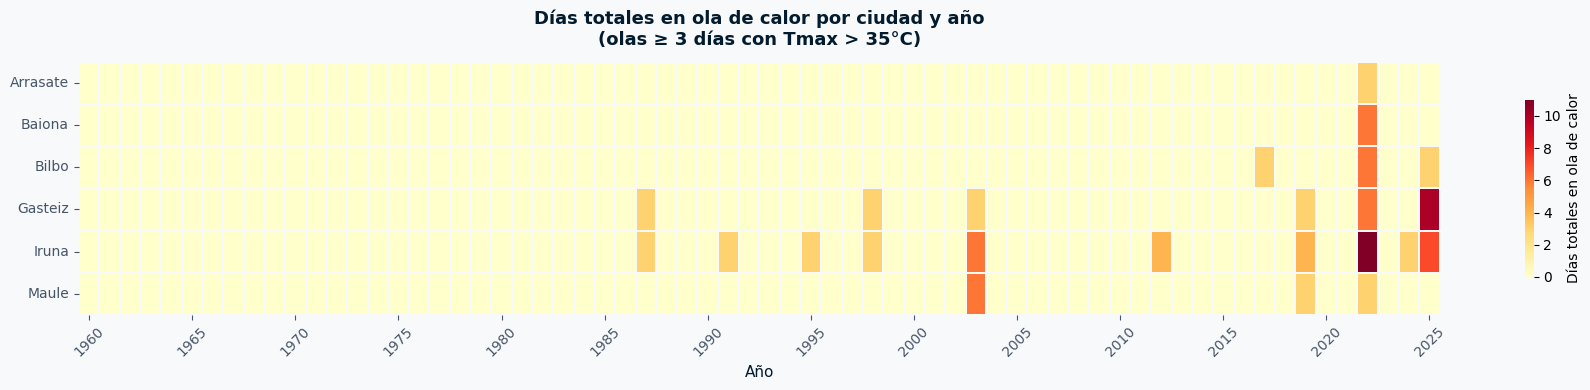

In [5]:
graficos_olas_calor.graficar_calendario_olas(datos_olas)

## 6. Resumen de olas de calor

In [6]:
import pandas as pd

rows = []
for r in datos_olas:
    ciudad = r['ciudad']
    olas   = r['olas']
    if olas.empty:
        continue
    rows.append({
        'Ciudad':              ciudad.nombre.capitalize(),
        'Dist. mar (km)':      ciudad.dist_mar,
        'Total olas':          len(olas),
        'Duración media (d)':  round(olas['duracion'].mean(), 1),
        'Duración máx. (d)':   int(olas['duracion'].max()),
        'Año más extremo':     int(olas.loc[olas['duracion'].idxmax(), 'año']),
    })

resumen = pd.DataFrame(rows).sort_values('Total olas', ascending=False)
display(resumen.style.background_gradient(subset=['Total olas', 'Duración máx. (d)'], cmap='YlOrRd'))

,Ciudad,Dist. mar (km),Total olas,Duración media (d),Duración máx. (d),Año más extremo
2,Iruna,61.800000,15,3.300000,4,2012
1,Gasteiz,58.200000,10,3.200000,4,1941
5,Maule,25.200000,5,3.000000,3,1947
0,Bilbo,11.100000,4,3.000000,3,2017
3,Baiona,1.500000,2,3.000000,3,2022
4,Arrasate,33.200000,1,3.000000,3,2022
